# SDSS Galaxies vs Quasars

Tasks
- Create arrays for the (u-g), (g-r), (r-i), (i-z) colors. Also create an array with the class labels where galaxy=0 and quasar=1.
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.

In [1]:
import sys
sys.path.append(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks")
import matplotlib.pyplot as plt 
import seaborn as sns
from Utilities import plot_settings
import numpy as np
import pandas as pd

In [2]:
data_path = r'C:\Users\ricca\OneDrive\Documents\Data\galaxyquasar.csv'
data = pd.read_csv(data_path)

In [3]:
ug = (data['u'] - data['g']).to_numpy()
gr = (data['g'] - data['r']).to_numpy()
ri = (data['r'] - data['i']).to_numpy()
iz = (data['i'] - data['z']).to_numpy()

true_labels = np.where(data['class'].to_numpy() == 'QSO', 1, 0)

In [4]:
X = np.vstack([ug, gr, ri, iz]).T
y = true_labels

## Data exploration

In [5]:
from matplotlib.lines import Line2D

In [6]:
df = pd.DataFrame(X, columns=['u-g', 'g-r', 'r-i', 'i-z'])
df['class'] = np.where(y == 1, 'QSO', 'non-QSO')

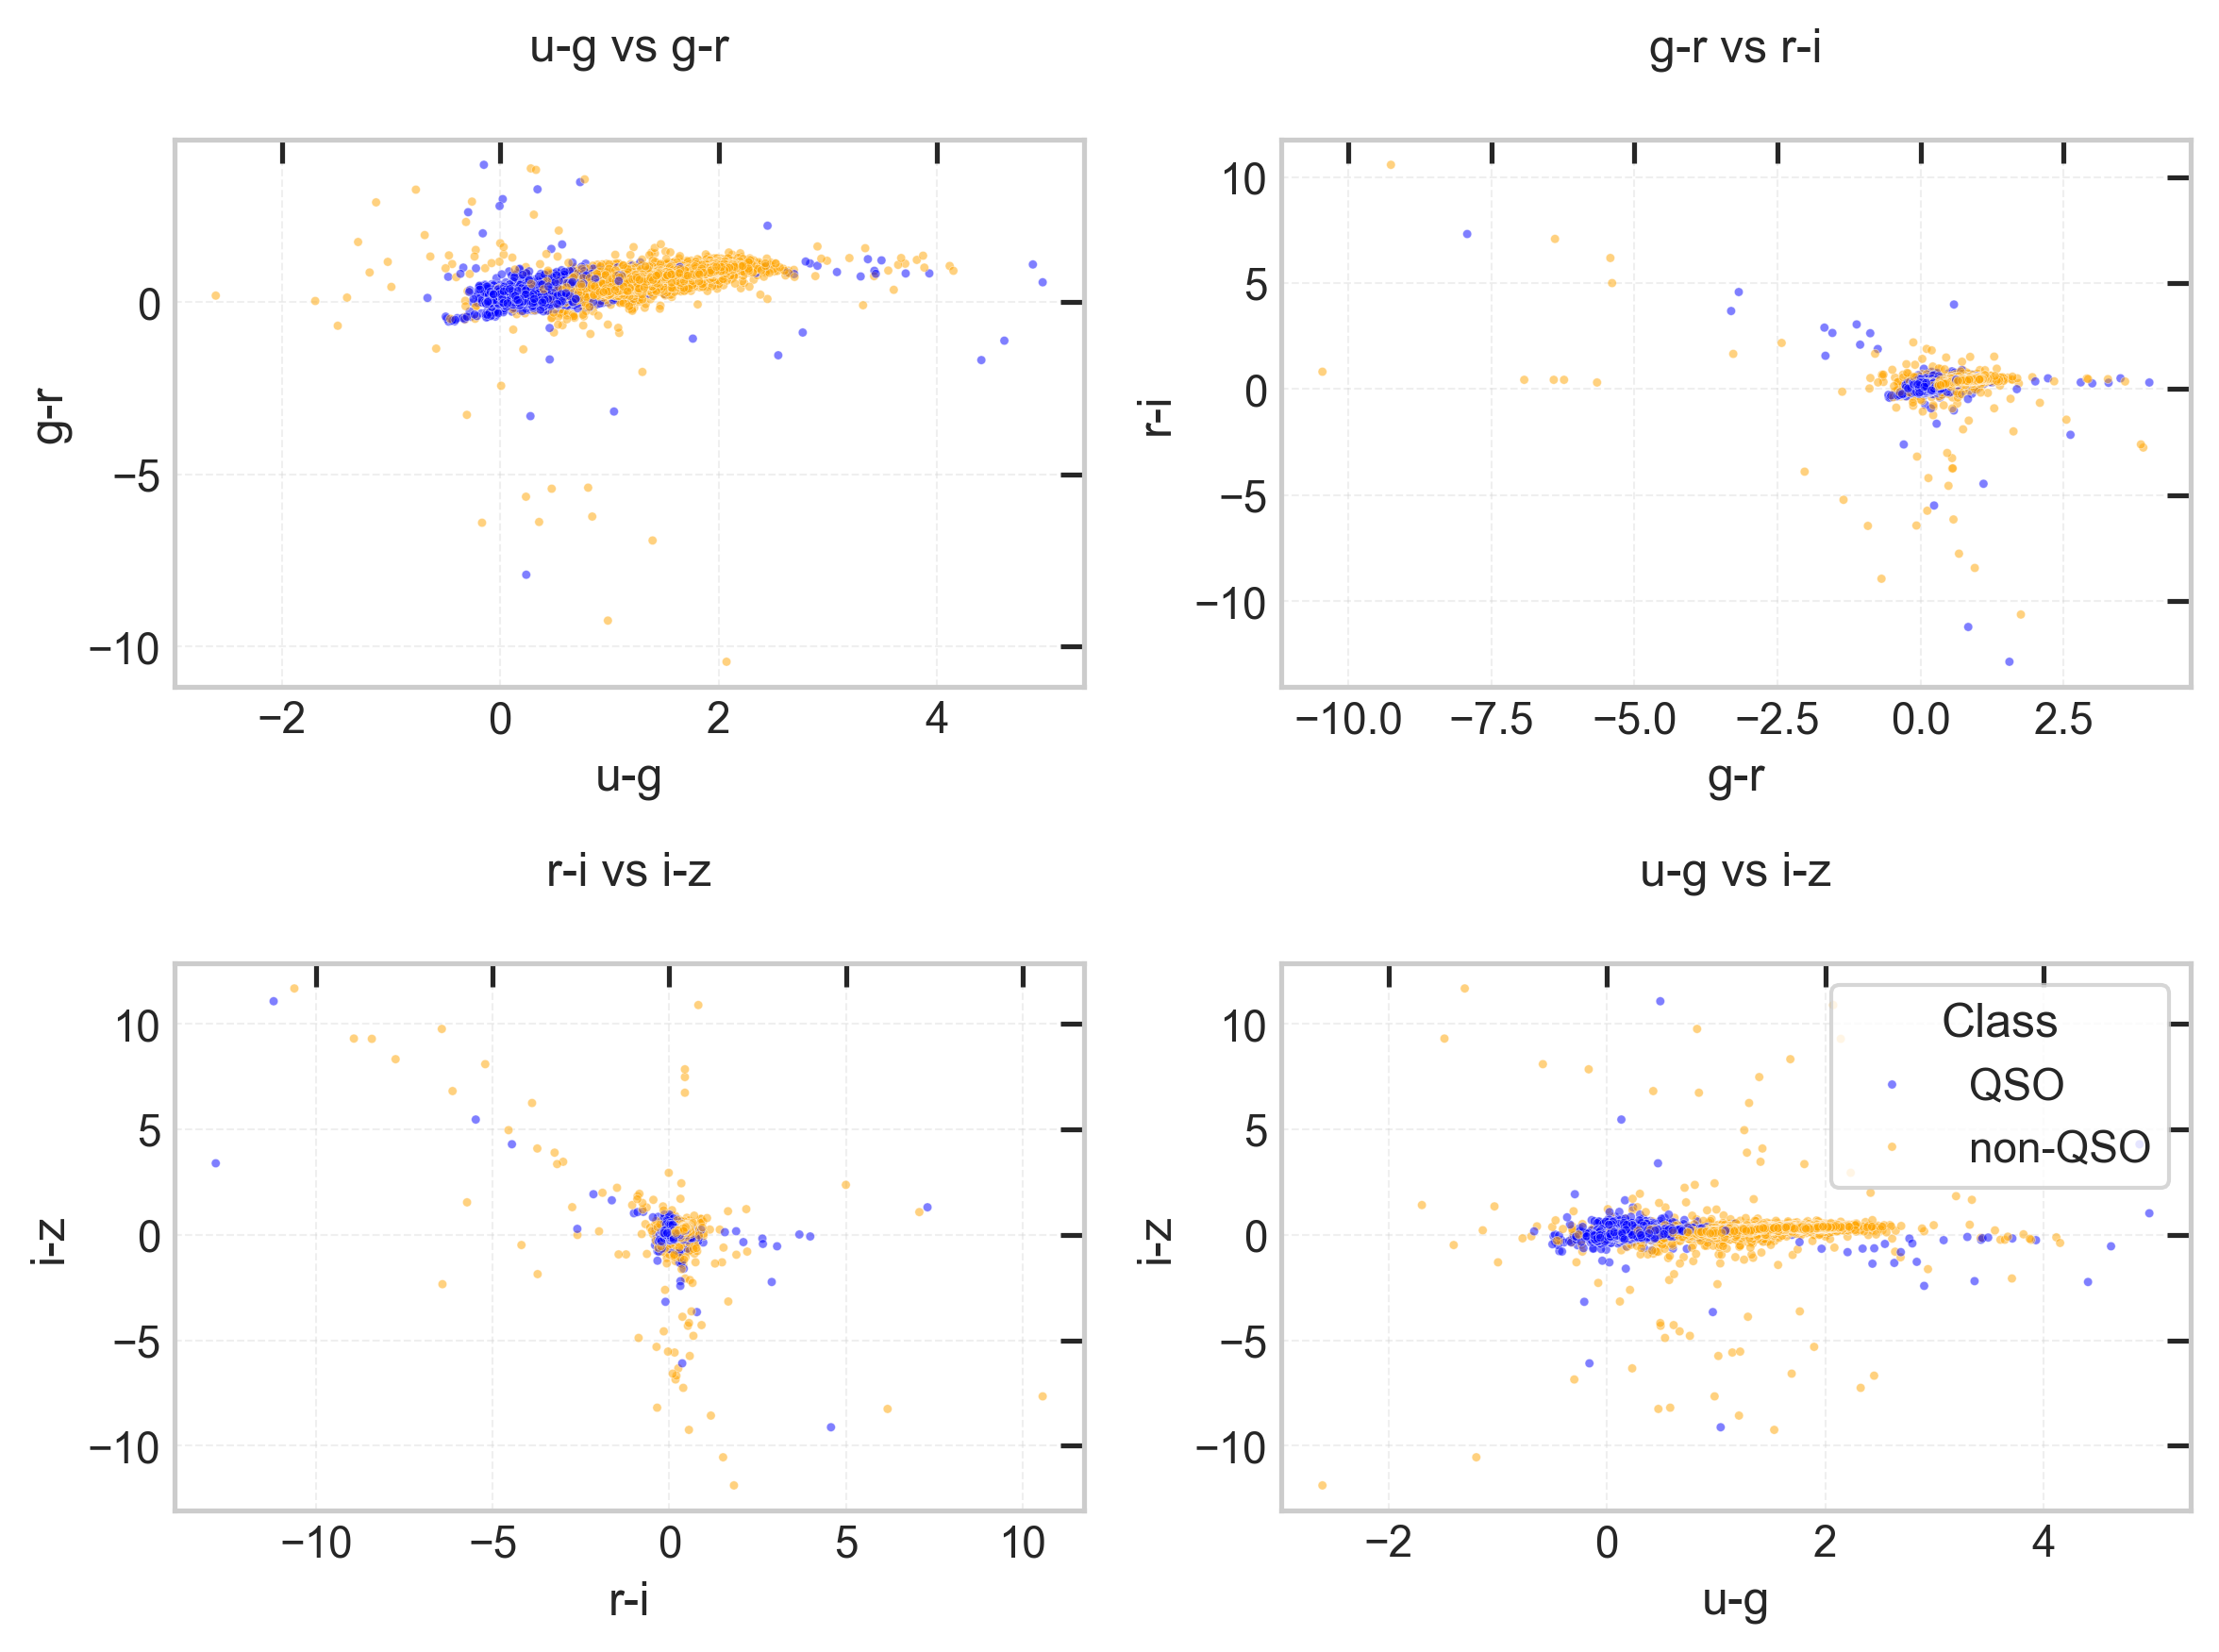

In [7]:
palette = {'non-QSO': 'orange', 'QSO': 'blue'}
sns.set_theme(style="whitegrid", rc={'figure.dpi': 300, 'savefig.dpi': 300})
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
sns.scatterplot(data=df, x='u-g', y='g-r', hue='class', palette=palette,
                s=5, alpha=0.5, ax=axs[0, 0], legend=False)
axs[0, 0].set_title('u-g vs g-r')

sns.scatterplot(data=df, x='g-r', y='r-i', hue='class', palette=palette,
                s=5, alpha=0.5, ax=axs[0, 1], legend=False)
axs[0, 1].set_title('g-r vs r-i')

sns.scatterplot(data=df, x='r-i', y='i-z', hue='class', palette=palette,
                s=5, alpha=0.5, ax=axs[1, 0], legend=False)
axs[1, 0].set_title('r-i vs i-z')

sns.scatterplot(data=df, x='u-g', y='i-z', hue='class', palette=palette,
                s=5, alpha=0.5, ax=axs[1, 1])
axs[1, 1].set_title('u-g vs i-z')

for ax in axs.flat:
    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)

handles, labels = axs[1, 1].get_legend_handles_labels()
axs[1, 1].legend(handles=handles, labels=labels, loc='upper right', title='Class')

plt.tight_layout()
plt.savefig("seaborn_color_color_qso_vs_nonqso.png", bbox_inches='tight')
plt.show()


Look at distribution of features

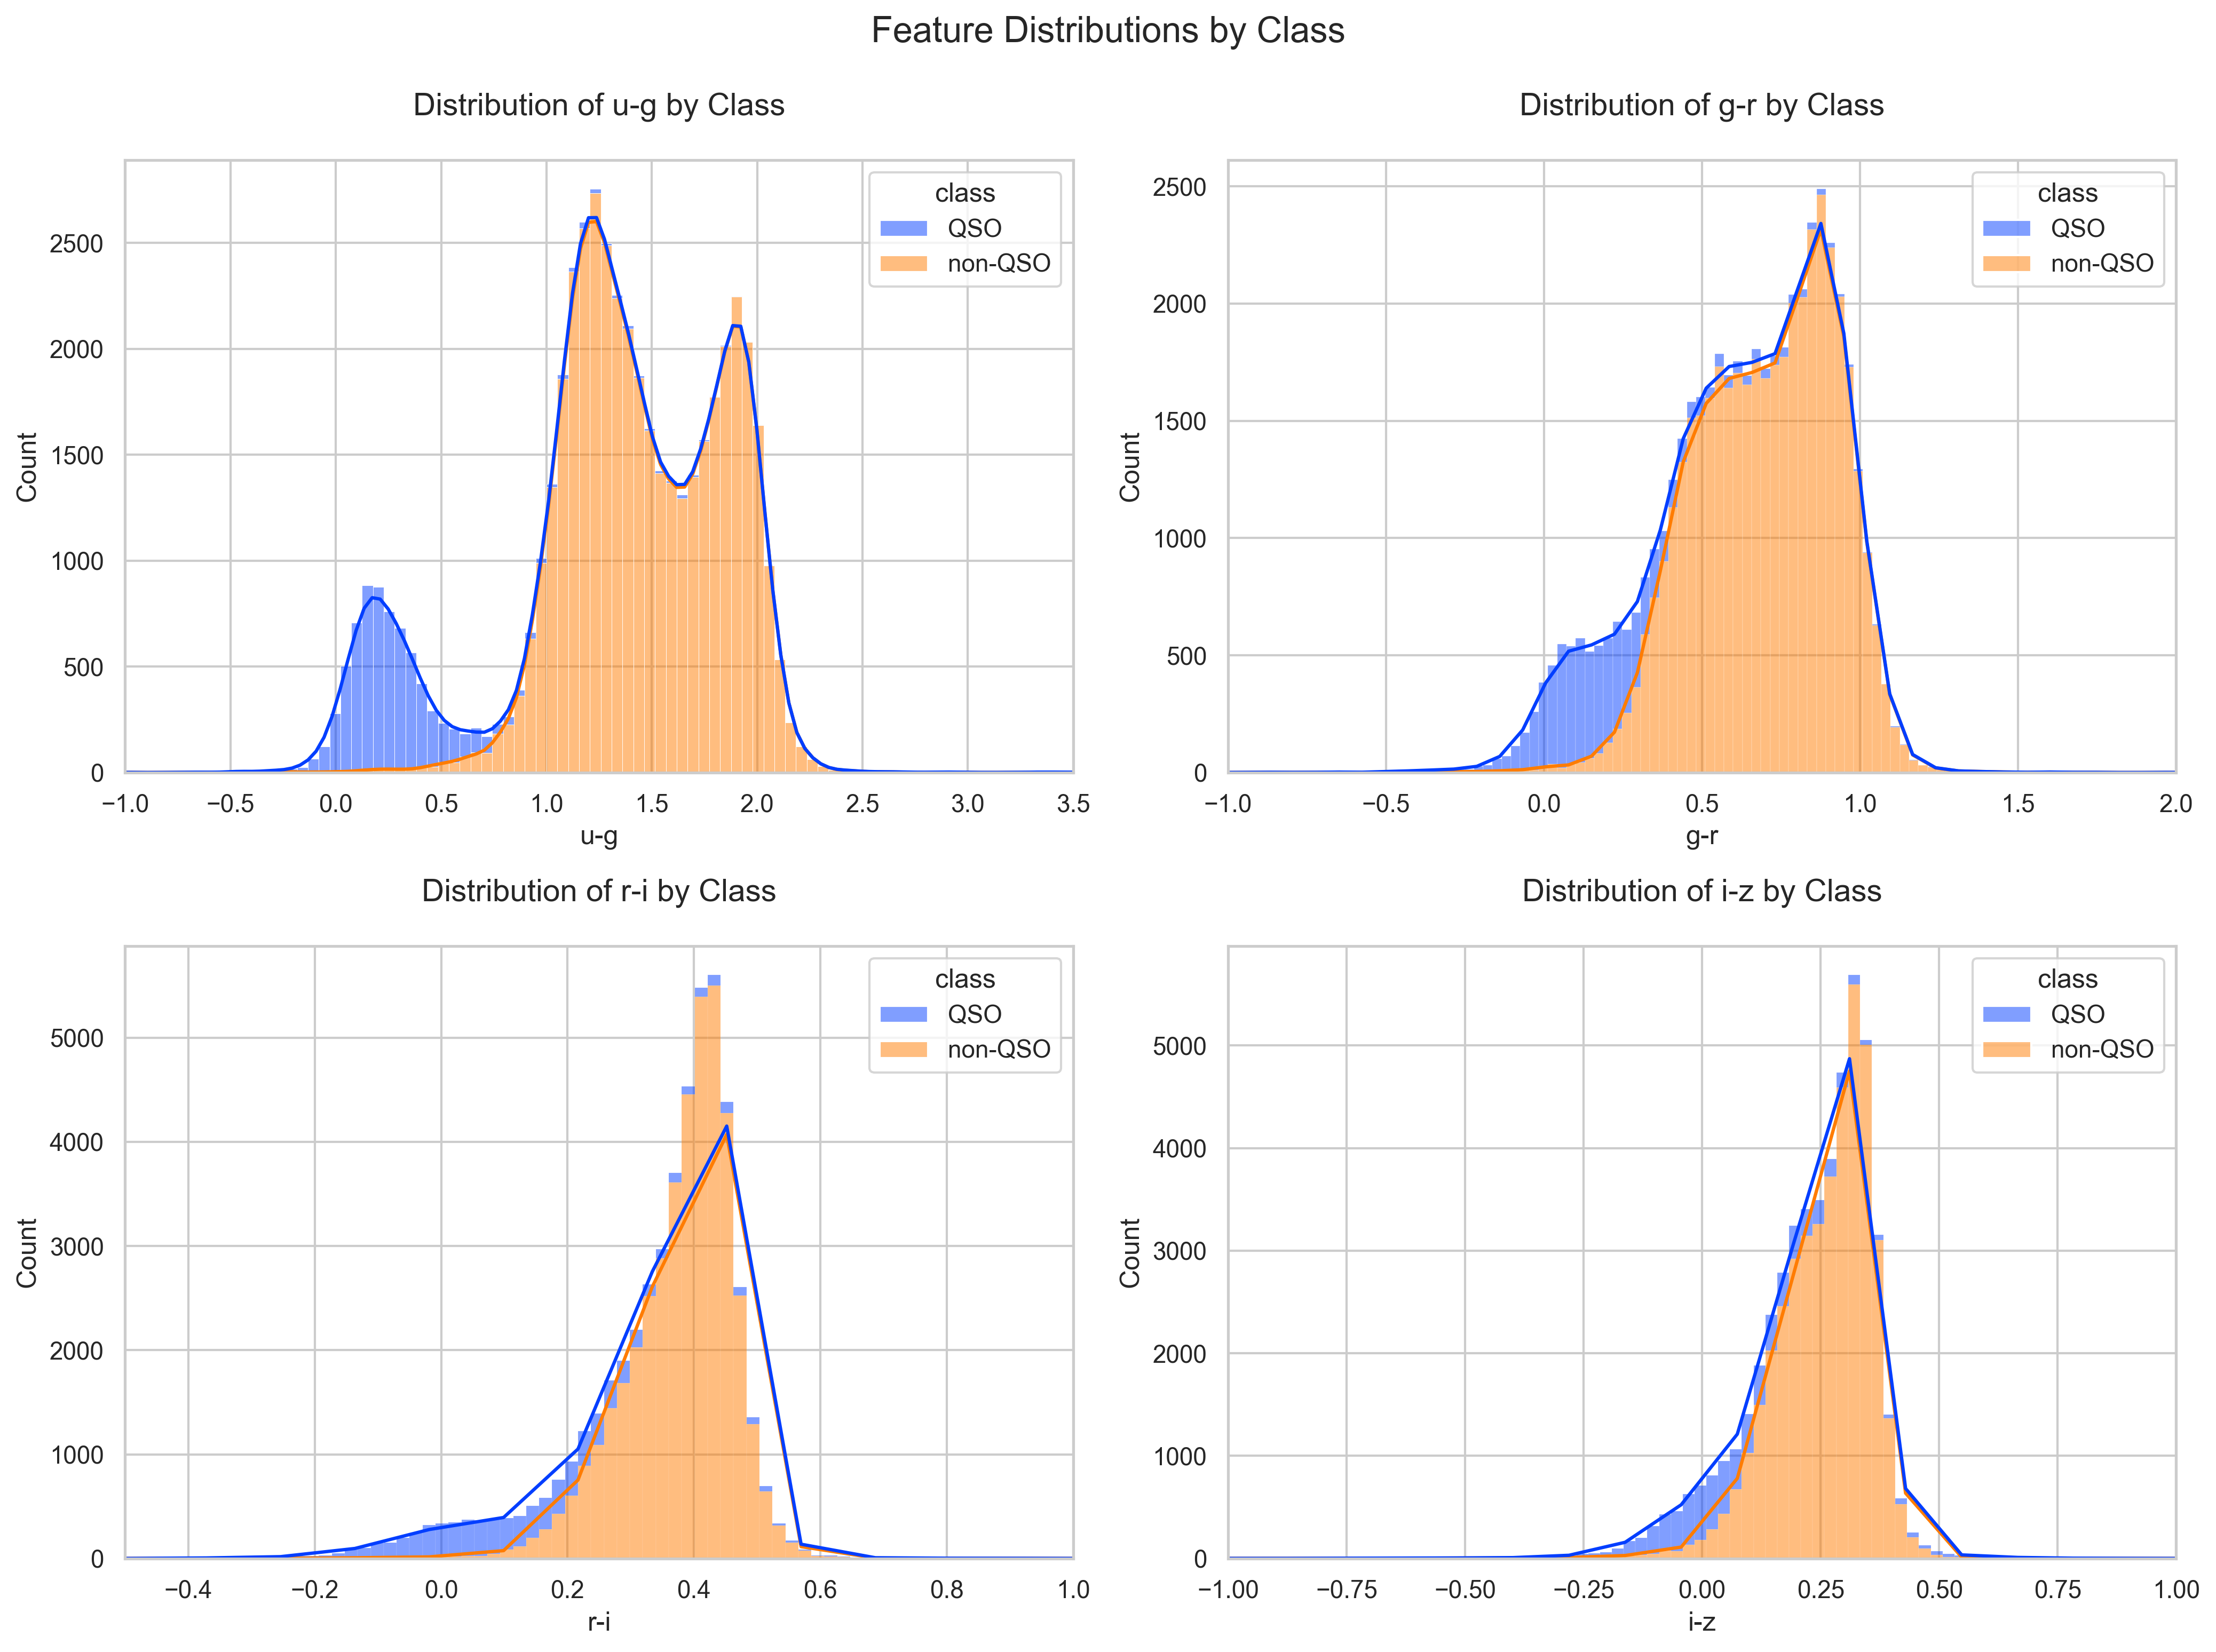

In [8]:
numeric_cols = ['u-g', 'g-r', 'r-i', 'i-z']
xlims = {
    'u-g': (-1, 3.5),
    'g-r': (-1, 2),
    'r-i': (-0.5, 1),
    'i-z': (-1, 1)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df, x=col, hue='class', multiple='stack',  # stack bars per class
        bins='scott', kde=True, palette='bright', ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col} by Class', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_xlim(xlims[col])

plt.tight_layout()
plt.suptitle('Feature Distributions by Class', fontsize=16, y=1.03);

I can clearly see that the feature $u-g$ exhibits a more aparent decision boundary (at $x \approx 0.7$) then the other features. I'll use this one.

## Genertive 1D Classification : Gaussian Naive Bayes

In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

In [10]:
col = 0

In [11]:
X = df[df.columns[col]].to_numpy().reshape(-1, 1)
Y = df['class'].to_numpy()

In [12]:
l = LabelBinarizer()
Y = l.fit_transform(Y).T[0]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=42)

In [14]:
GNB = GaussianNB()
GNB.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [15]:
predicted = GNB.predict(X_test)

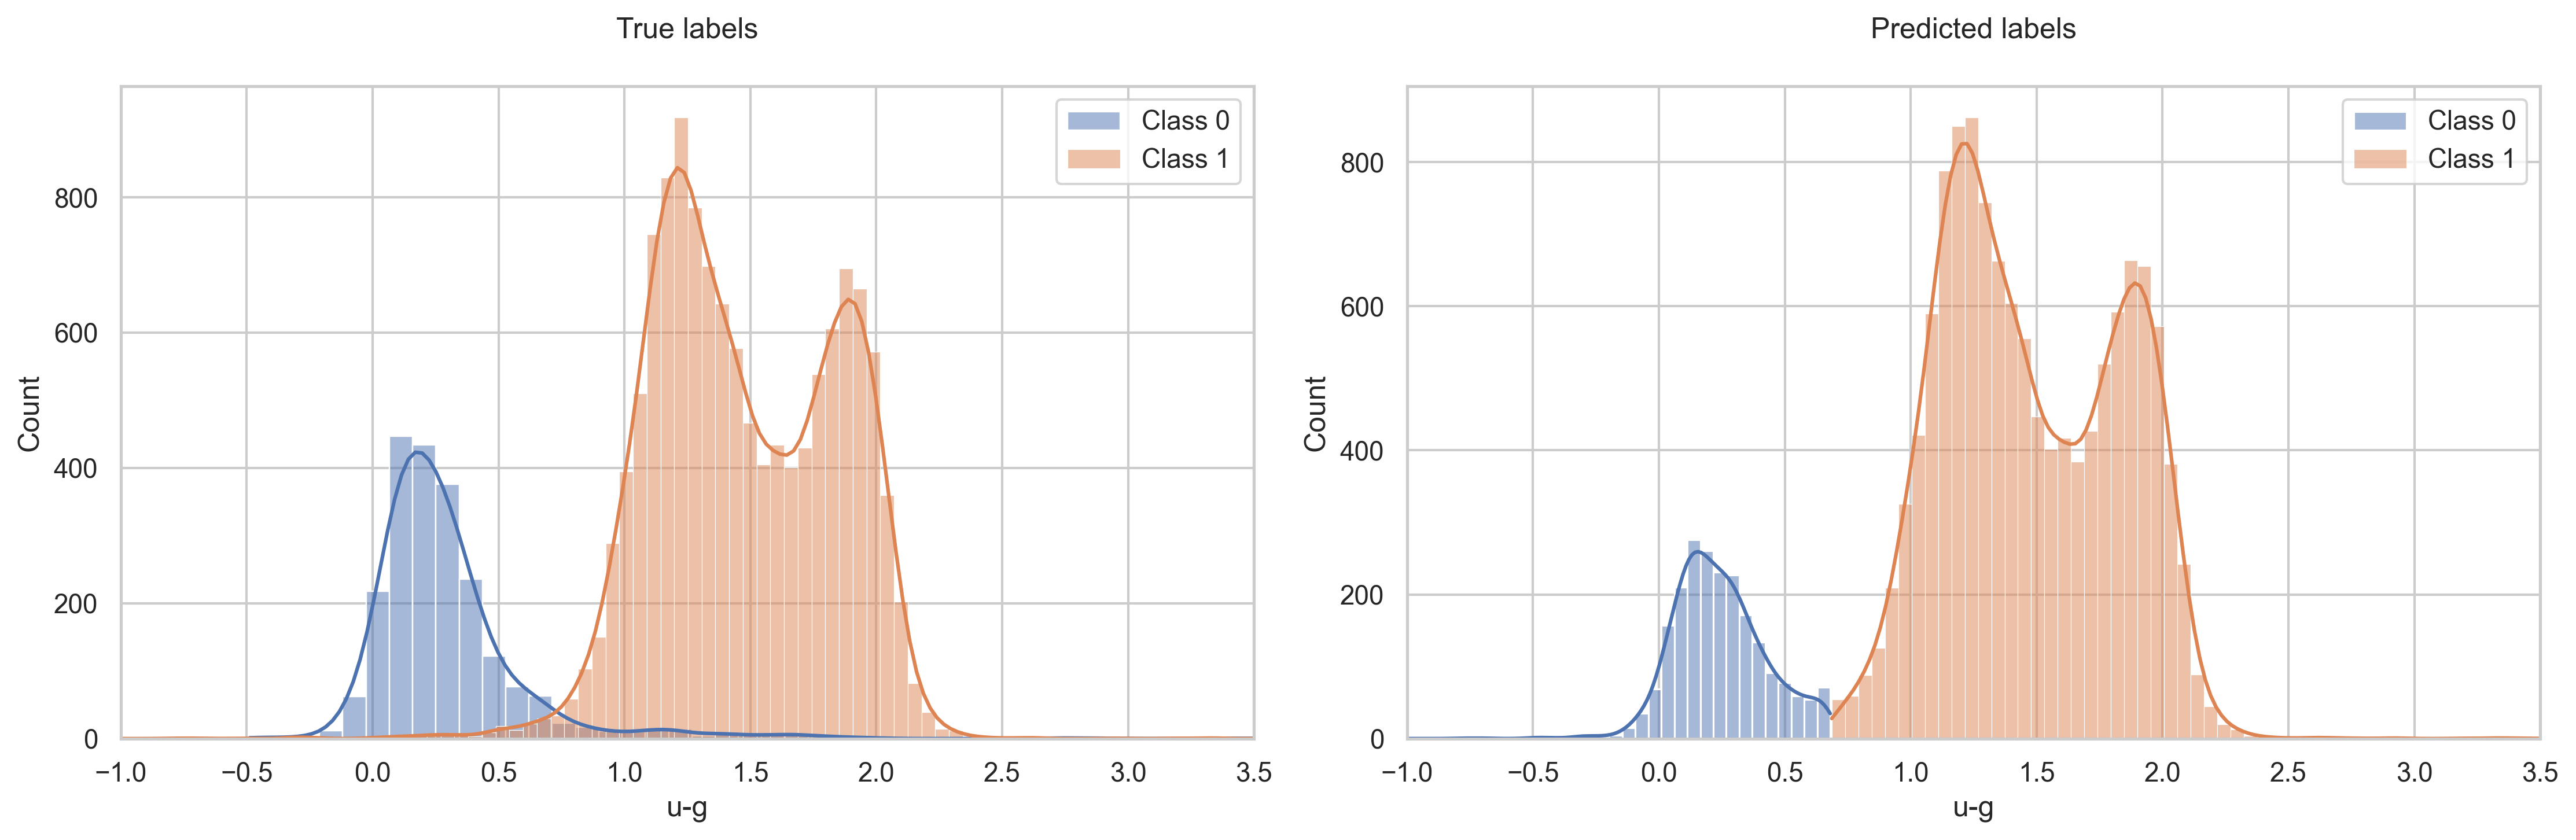

In [16]:
plt.figure(figsize=(15, 5))

# --- Left: True Labels ---
plt.subplot(1, 2, 1)
for label in np.unique(y_test):
    sns.histplot(
        X_test[y_test == label, 0],
        label=f"Class {label}",
        bins='scott',
        kde=True,
        stat="count",
        element="bars",
        common_norm=False
    )
plt.title('True labels')
plt.xlabel('u-g')
plt.ylabel('Count')
plt.xlim(-1, 3.5)
plt.legend()

# --- Right: Predicted Labels ---
plt.subplot(1, 2, 2)
for label in np.unique(predicted):
    sns.histplot(
        X_test[predicted == label, 0],
        label=f"Class {label}",
        bins='scott',
        kde=True,
        stat="count",
        element="bars",
        common_norm=False
    )
plt.title('Predicted labels')
plt.xlabel('u-g')
plt.ylabel('Count')
plt.xlim(-1, 3.5)
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming binary classification with labels 0 and 1
cm = confusion_matrix(y_test, predicted)
tn, fp, fn, tp = cm.ravel()

print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

True Positives (TP): 12684
True Negatives (TN): 2037
False Positives (FP): 151
False Negatives (FN): 128


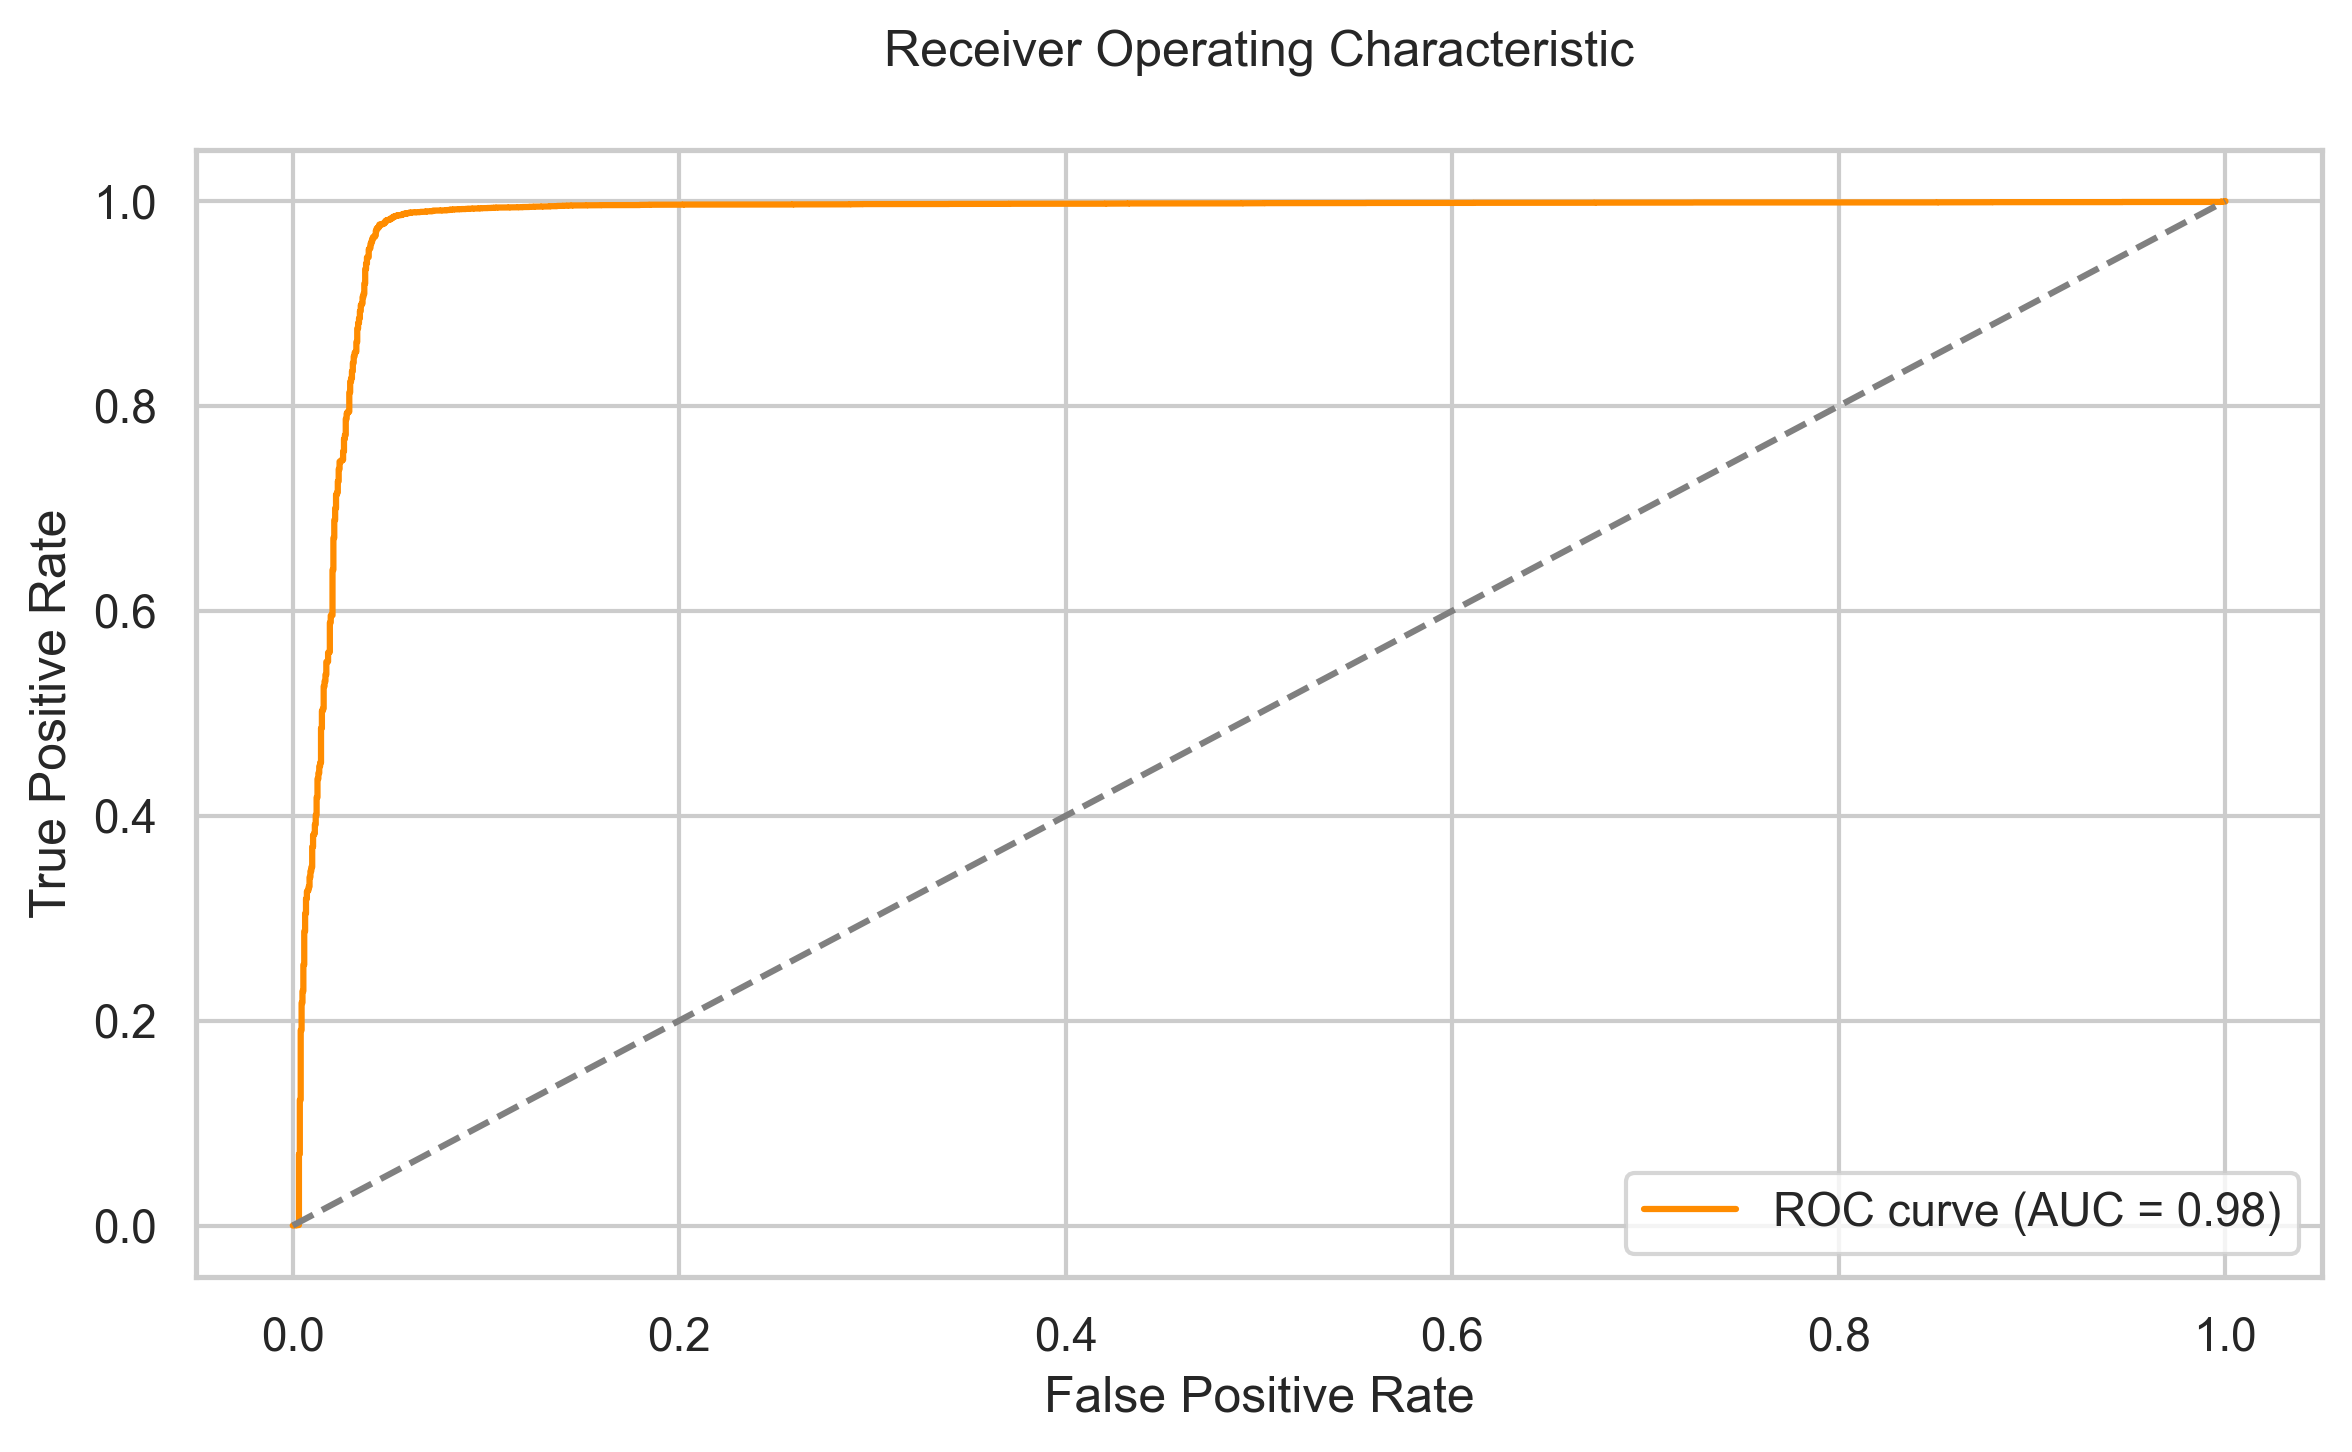

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for class 1
y_scores = GNB.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()

Comment on TP vs FP plot:
- AUC ≈ 0.98, which indicates excellent separability between the two classes.
- The curve quickly rises to a True Positive Rate (TPR) close to 1 while keeping the False Positive Rate (FPR) near 0, which means the model rarely misclassifies negatives as positives.
- The ROC curve being far above the diagonal (random guess line) shows your classifier is performing significantly better than chance.
Thus this model can effectively distinguish between the two classes over a wide range of thresholds.

**The model ranks positives well (high ROC AUC), but actual predictions (e.g., at default threshold 0.5) may lead to many false positives.**

\
Maybe this is due to class imbalance

In [19]:
print(f'QSO true labels over total number of labels : {len(y_train[y_train==1])/len(y_train)*100 :.3} %')

QSO true labels over total number of labels : 85.9 %


Yes, I do have heavily imbalanced classes. I have to see what happens if I take into account classes imbalances by resampling. I know that SVM works well with unbalanced classes. Also GNB assumes independence between features, but here a point is just an image seen with one of four possible filters, thus statistical independence between features seems an unrealistic hypothesis.

Support Vector Classifier

In [74]:
X = np.vstack([ug, gr, ri, iz]).T
y = true_labels

In [75]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, shuffle=True, random_state=42)
X_test, X_cv, y_test, y_cv = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=True, random_state=42)

Do I really need 4 dimesnions?

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [77]:
S = StandardScaler()
X_scaled= S.fit_transform(X)

Text(0, 0.5, 'Explained variance ratio')

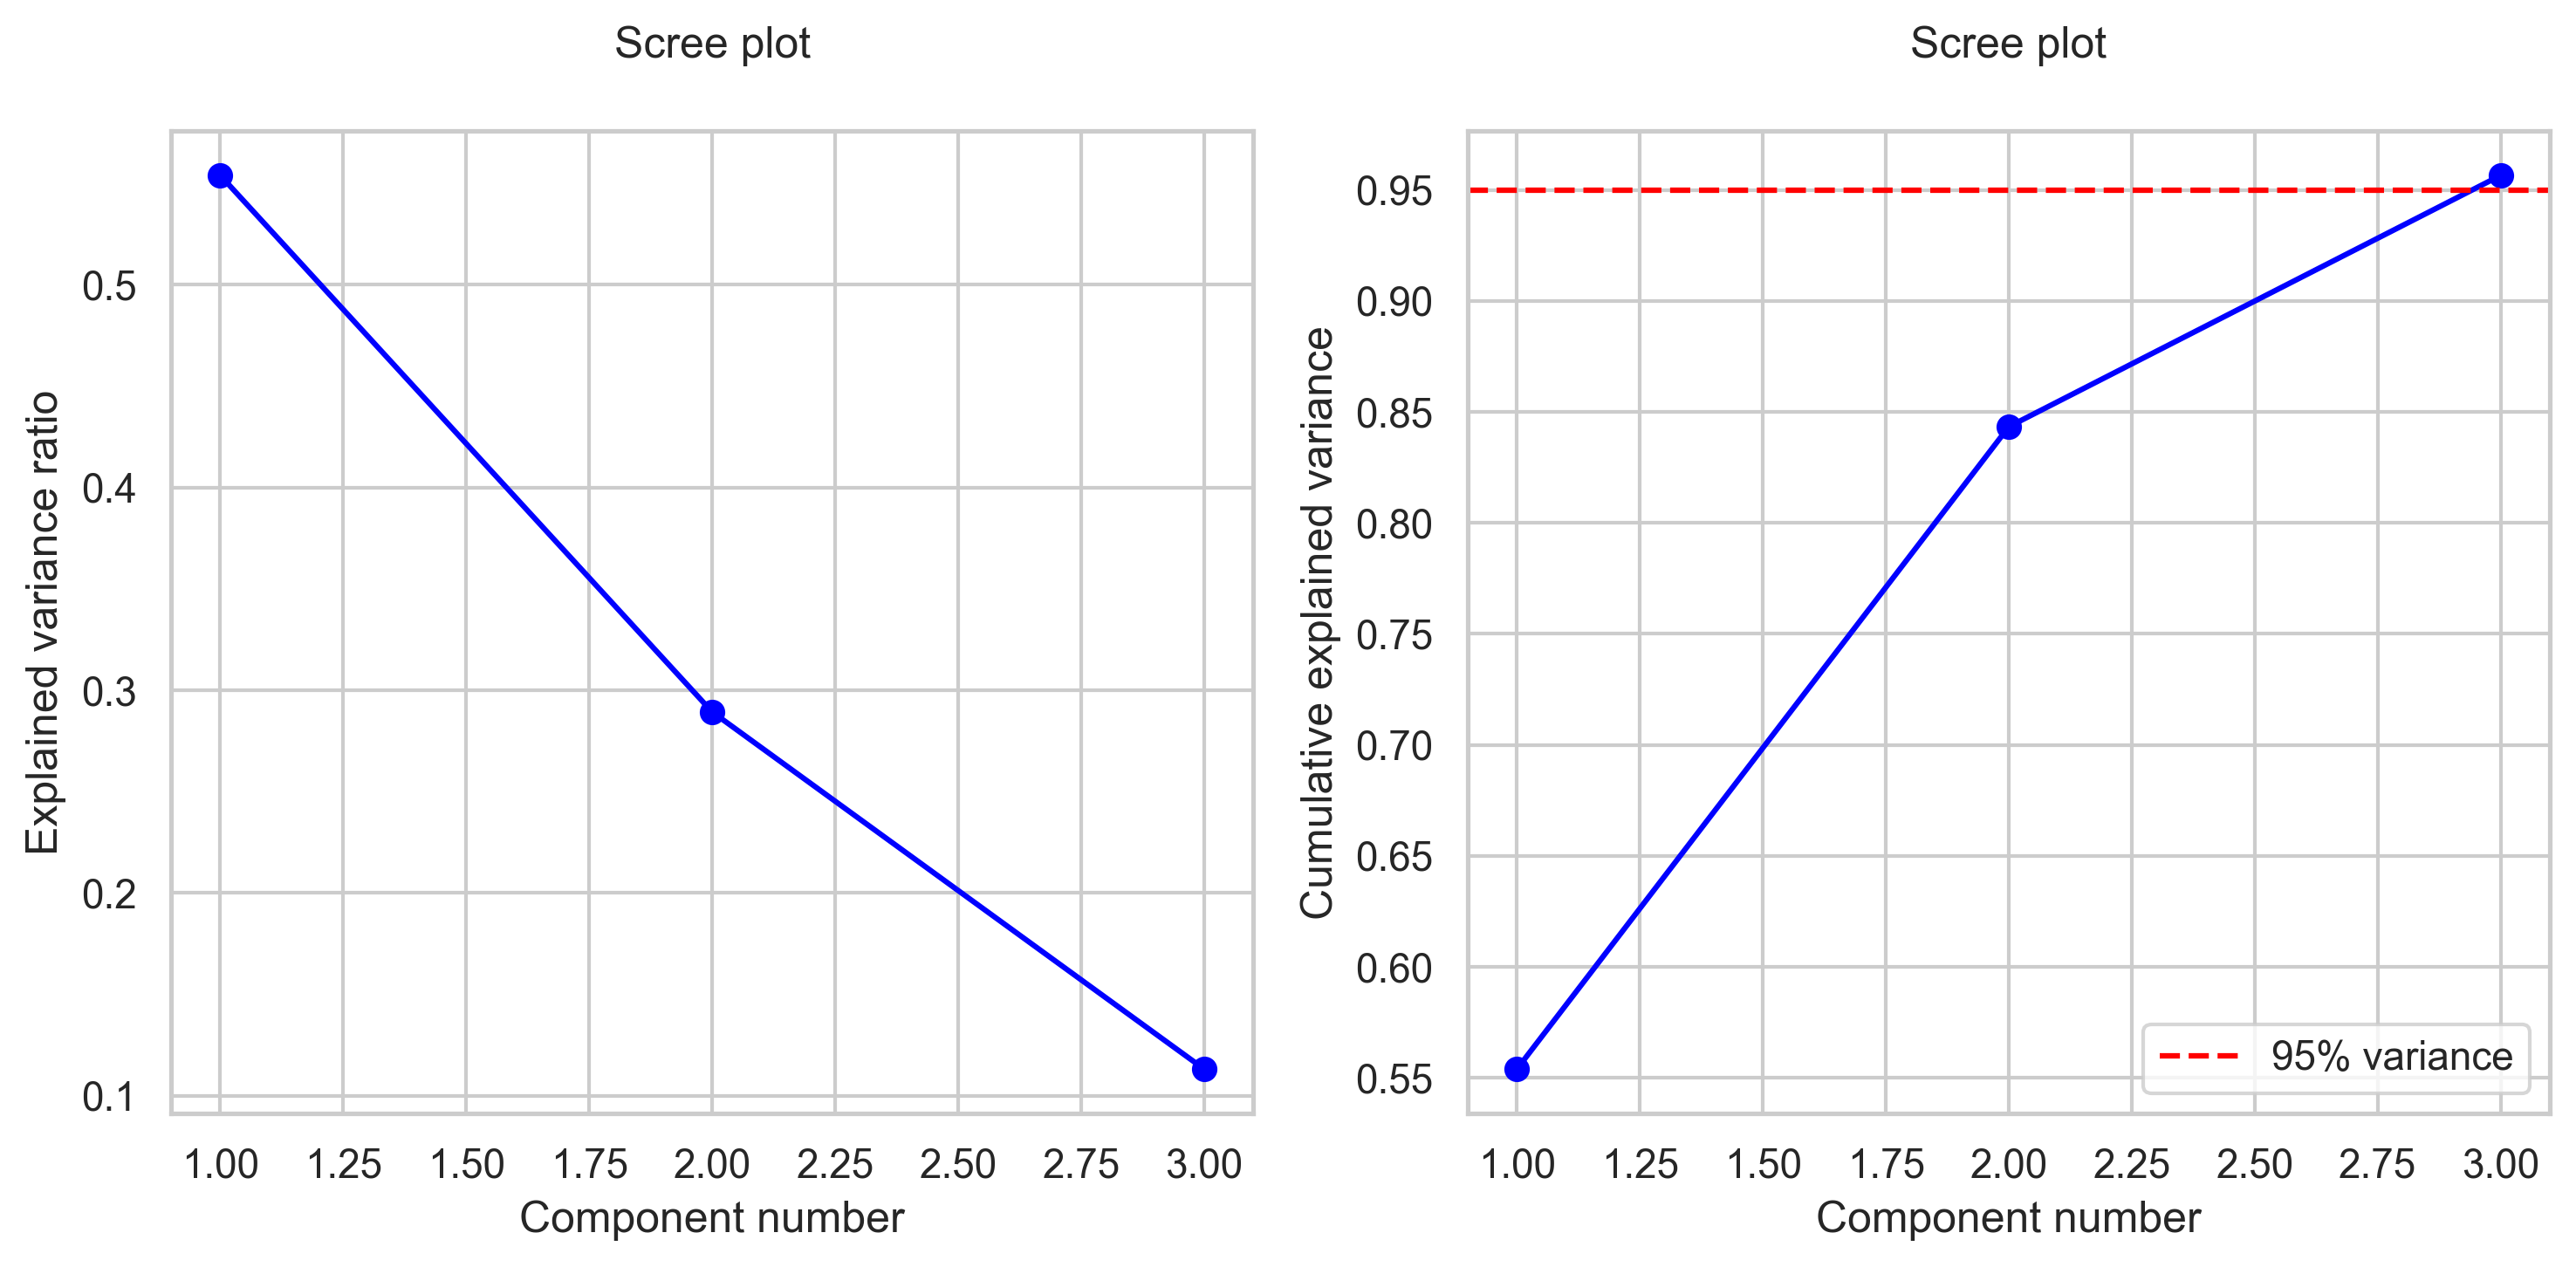

In [78]:
pca = PCA(n_components=3)
pca.fit(X_scaled)

fig, axs = plt.subplots(1, 2)
axs[1].plot(range(1,pca.n_components+1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-', color='blue')
axs[1].set_title('Scree plot')
axs[1].set_xlabel('Component number')
axs[1].axhline(0.95, 0, 1, linestyle='--', color='red', label='95% variance')
axs[1].set_ylabel('Cumulative explained variance')
axs[1].legend()

axs[0].plot(range(1,pca.n_components+1), pca.explained_variance_ratio_, marker='o', linestyle='-', color='blue')
axs[0].set_title('Scree plot')
axs[0].set_xlabel('Component number')
axs[0].set_ylabel('Explained variance ratio')

PCA says I can use 3 of the 4 principal components and still explain more then $95 \%$ of the explained variance.

In [79]:
X_train  = pca.transform(S.transform(X_train))
X_test   = pca.transform(S.transform(X_test))
X_cv     = pca.transform(S.transform(X_cv))

In [80]:
from sklearn.svm import SVC

In [ ]:
svc = 

In [82]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, roc_curve, auc

C_values = [0.1, 1, 10, 100]
kf = KFold(n_splits=5, shuffle=True, random_state=10)

mean_scores = {}
test_roc_data = {}

n_classes = 2

for C in C_values:
    print(f'Cross-validating on C...{C}')
    scores = []
    
    for train_index, val_index in kf.split(X_train):
        X_tr, X_val_fold = X_train[train_index], X_train[val_index]
        y_tr, y_val_fold = y_train[train_index], y_train[val_index]
        
        model = SVC(C=C,
                    kernel='rbf',
                    gamma='auto',
                    class_weight='balanced',
                    decision_function_shape='ovo'
                    )
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val_fold)
        score = accuracy_score(y_val_fold, y_pred)
        scores.append(score)
    
    mean_scores[C] = np.mean(scores)
    print(f"C={C} | Mean CV accuracy: {mean_scores[C]:.4f}")
    
    # Ri-allena modello su tutto il train set con il C corrente
    final_model = SVC(C=C, kernel='rbf', gamma='auto', class_weight='balanced', decision_function_shape='ovo', probability=False)
    final_model.fit(X_train, y_train)
    
    y_score = final_model.decision_function(X_test)    
    
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    test_roc_data[C] = (fpr, tpr, roc_auc)

# Trova miglior C
best_C = max(mean_scores, key=mean_scores.get)
print(f"\nBest C found manually: {best_C}")

Cross-validating on C...0.1
C=0.1 | Mean CV accuracy: 0.9659
Cross-validating on C...1
C=1 | Mean CV accuracy: 0.9691
Cross-validating on C...10
C=10 | Mean CV accuracy: 0.9699
Cross-validating on C...100
C=100 | Mean CV accuracy: 0.9690

Best C found manually: 10


(0.9, 1.01)

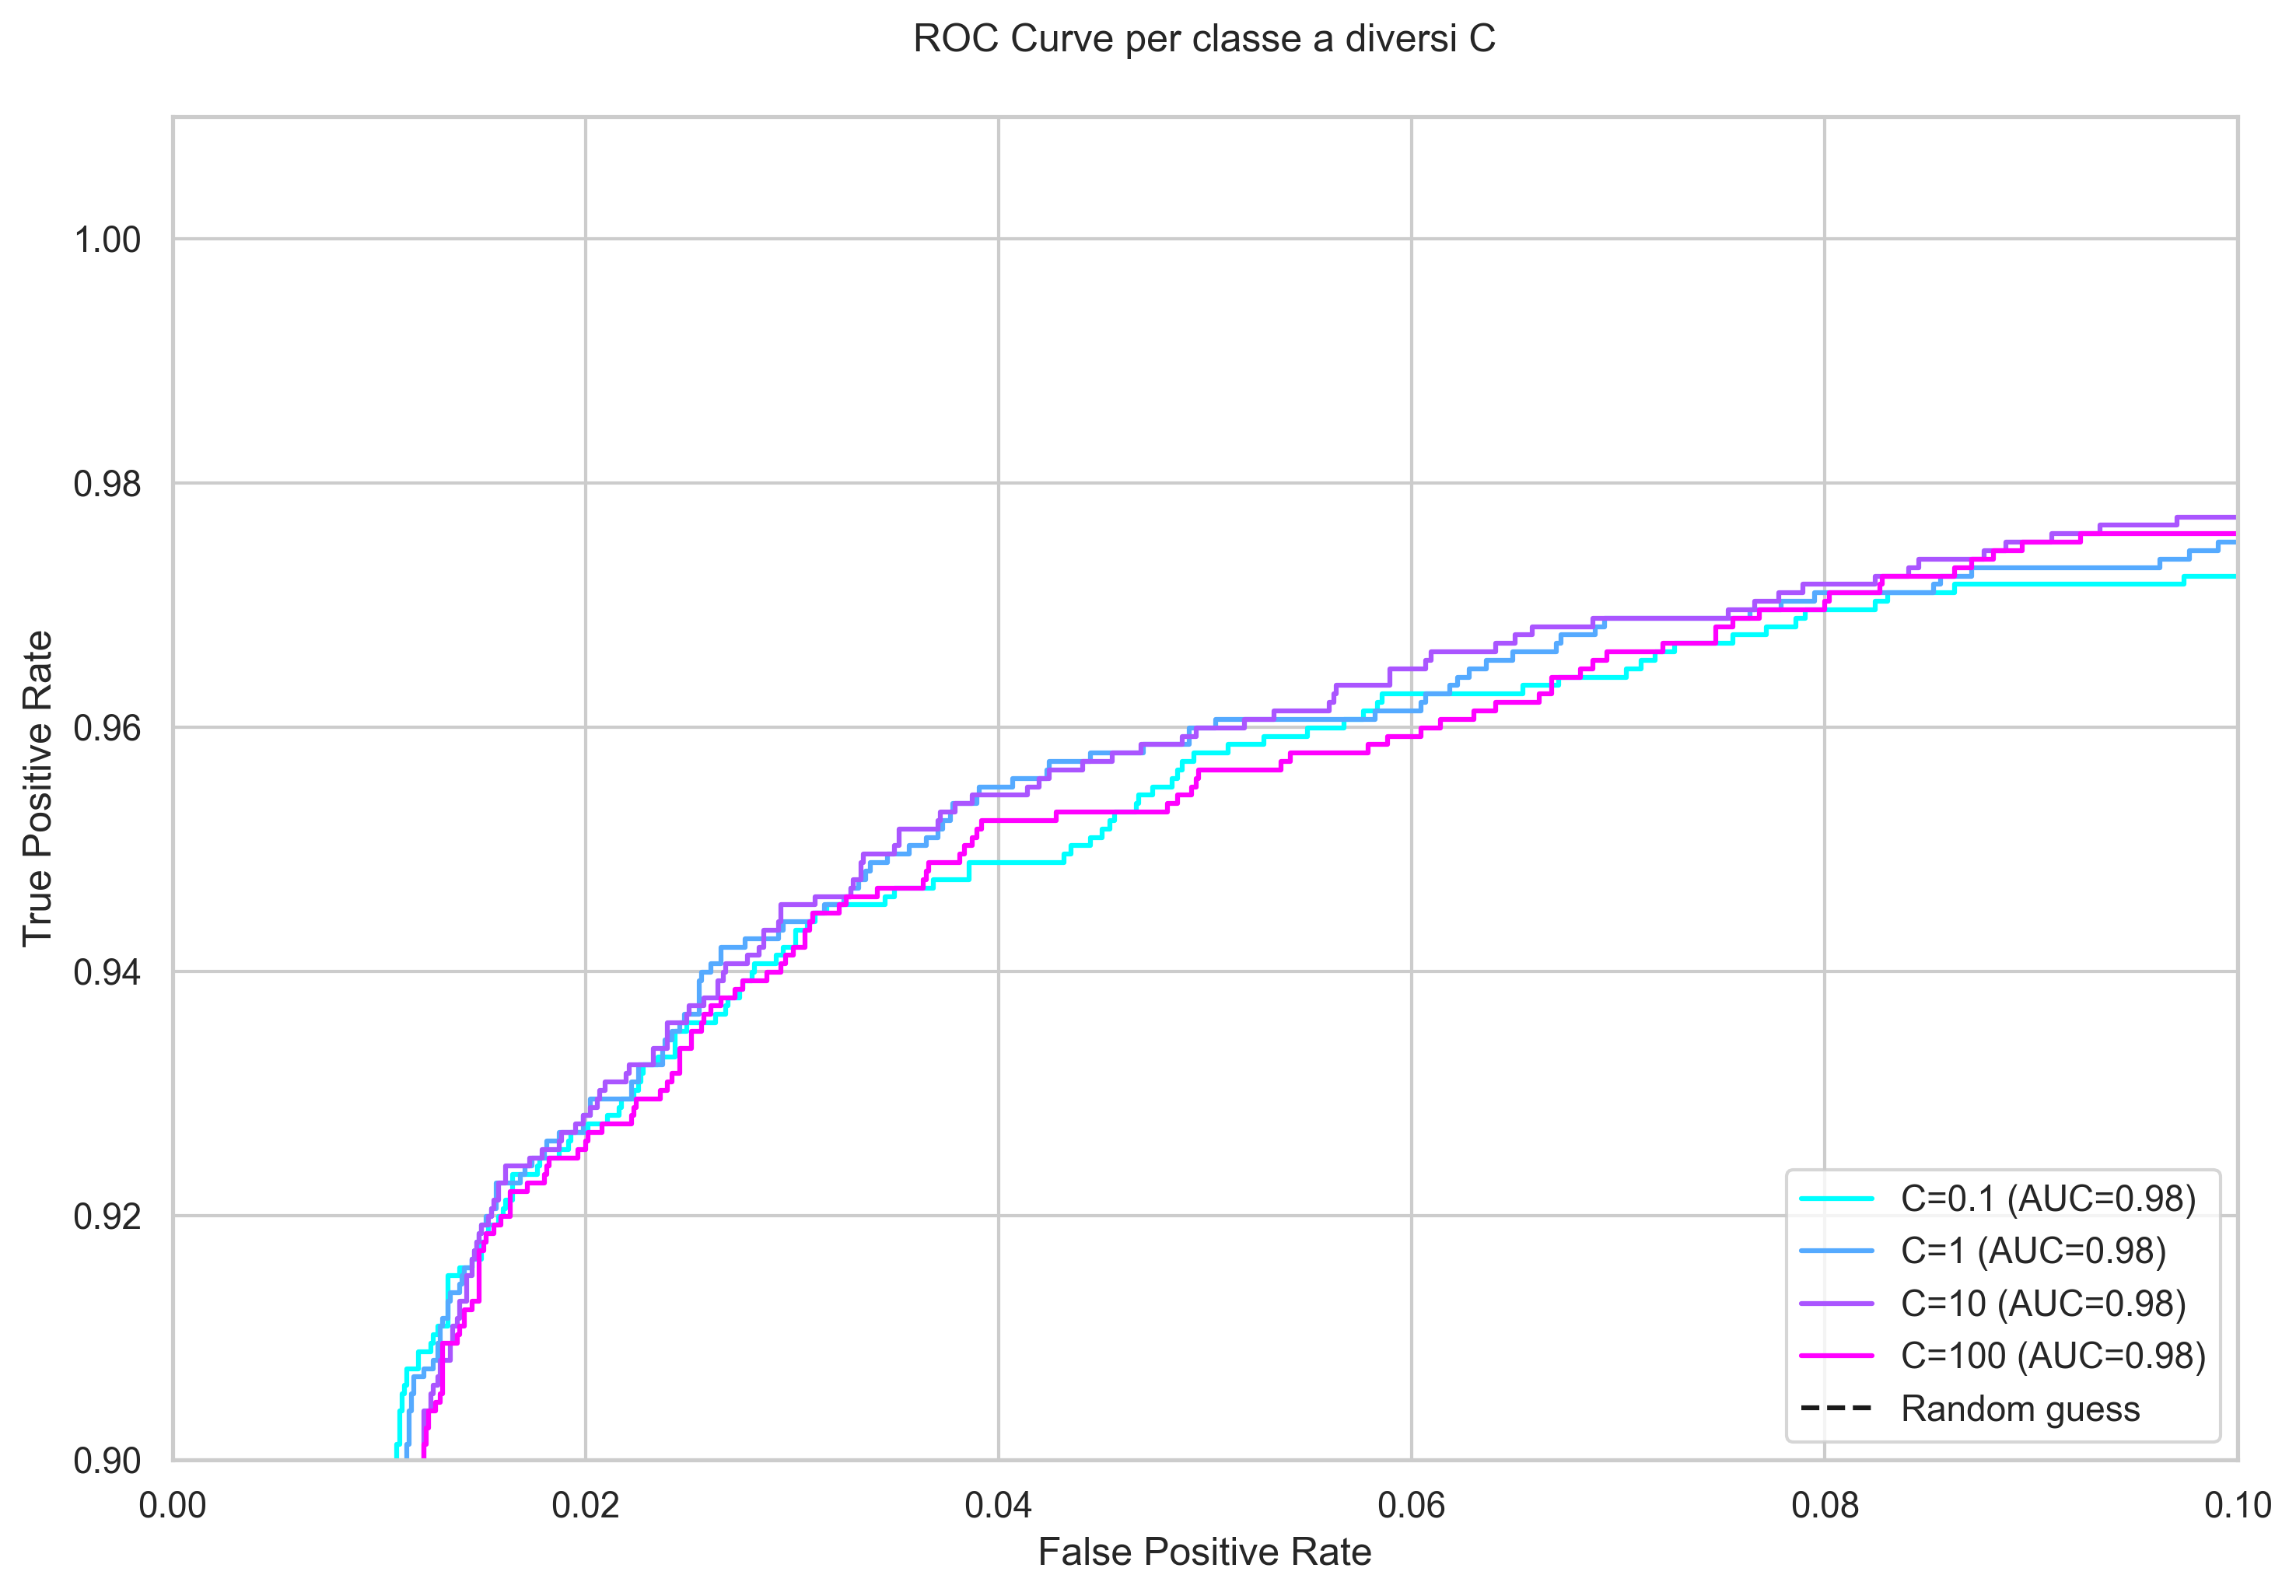

In [83]:
plt.figure(figsize=(10, 7))
colors = plt.cm.cool(np.linspace(0, 1, len(C_values)))

for i, C in enumerate(C_values):
    fpr, tpr, roc_auc = test_roc_data[C]
    plt.plot(fpr, tpr,
             label=f'C={C} (AUC={roc_auc:.2f})',
             color=colors[i])
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve per classe a diversi C')
plt.legend(loc='lower right')
plt.grid(True)
plt.xlim(0, 0.1)
plt.ylim(0.9, 1.01)

In [95]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

def plot_svc_decision_function_3d(clf, ax=None, grid_size=30, SV=False):
    """Plot the decision function for a 3D SVC"""
    if ax is None:
        ax = plt.gca(projection='3d')

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    zlim = ax.get_zlim()

    x = np.linspace(xlim[0], xlim[1], grid_size)
    y = np.linspace(ylim[0], ylim[1], grid_size)
    z = np.linspace(zlim[0], zlim[1], grid_size)

    xx, yy, zz = np.meshgrid(x, y, z)

    # Flatten grid for batch decision function computation
    grid_points = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
    decision_values = clf.decision_function(grid_points)
    decision_values = decision_values.reshape(xx.shape)

    # Let's plot slices at middle z-plane to visualize decision boundaries
    mid_z_idx = grid_size // 2
    cset = ax.contourf(xx[:, :, mid_z_idx], yy[:, :, mid_z_idx], 
                      decision_values[:, :, mid_z_idx], 
                      levels=[-1, 0, 1], alpha=0.3, cmap='coolwarm')

    # Optionally, plot support vectors
    sv = clf.support_vectors_
    if SV:
        ax.scatter(sv[:, 0], sv[:, 1], sv[:, 2], s=20, facecolors='red', edgecolors='k', label='Support Vectors')

    return ax

C:\Users\ricca\AppData\Local\Temp\ipykernel_17000\3255189025.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


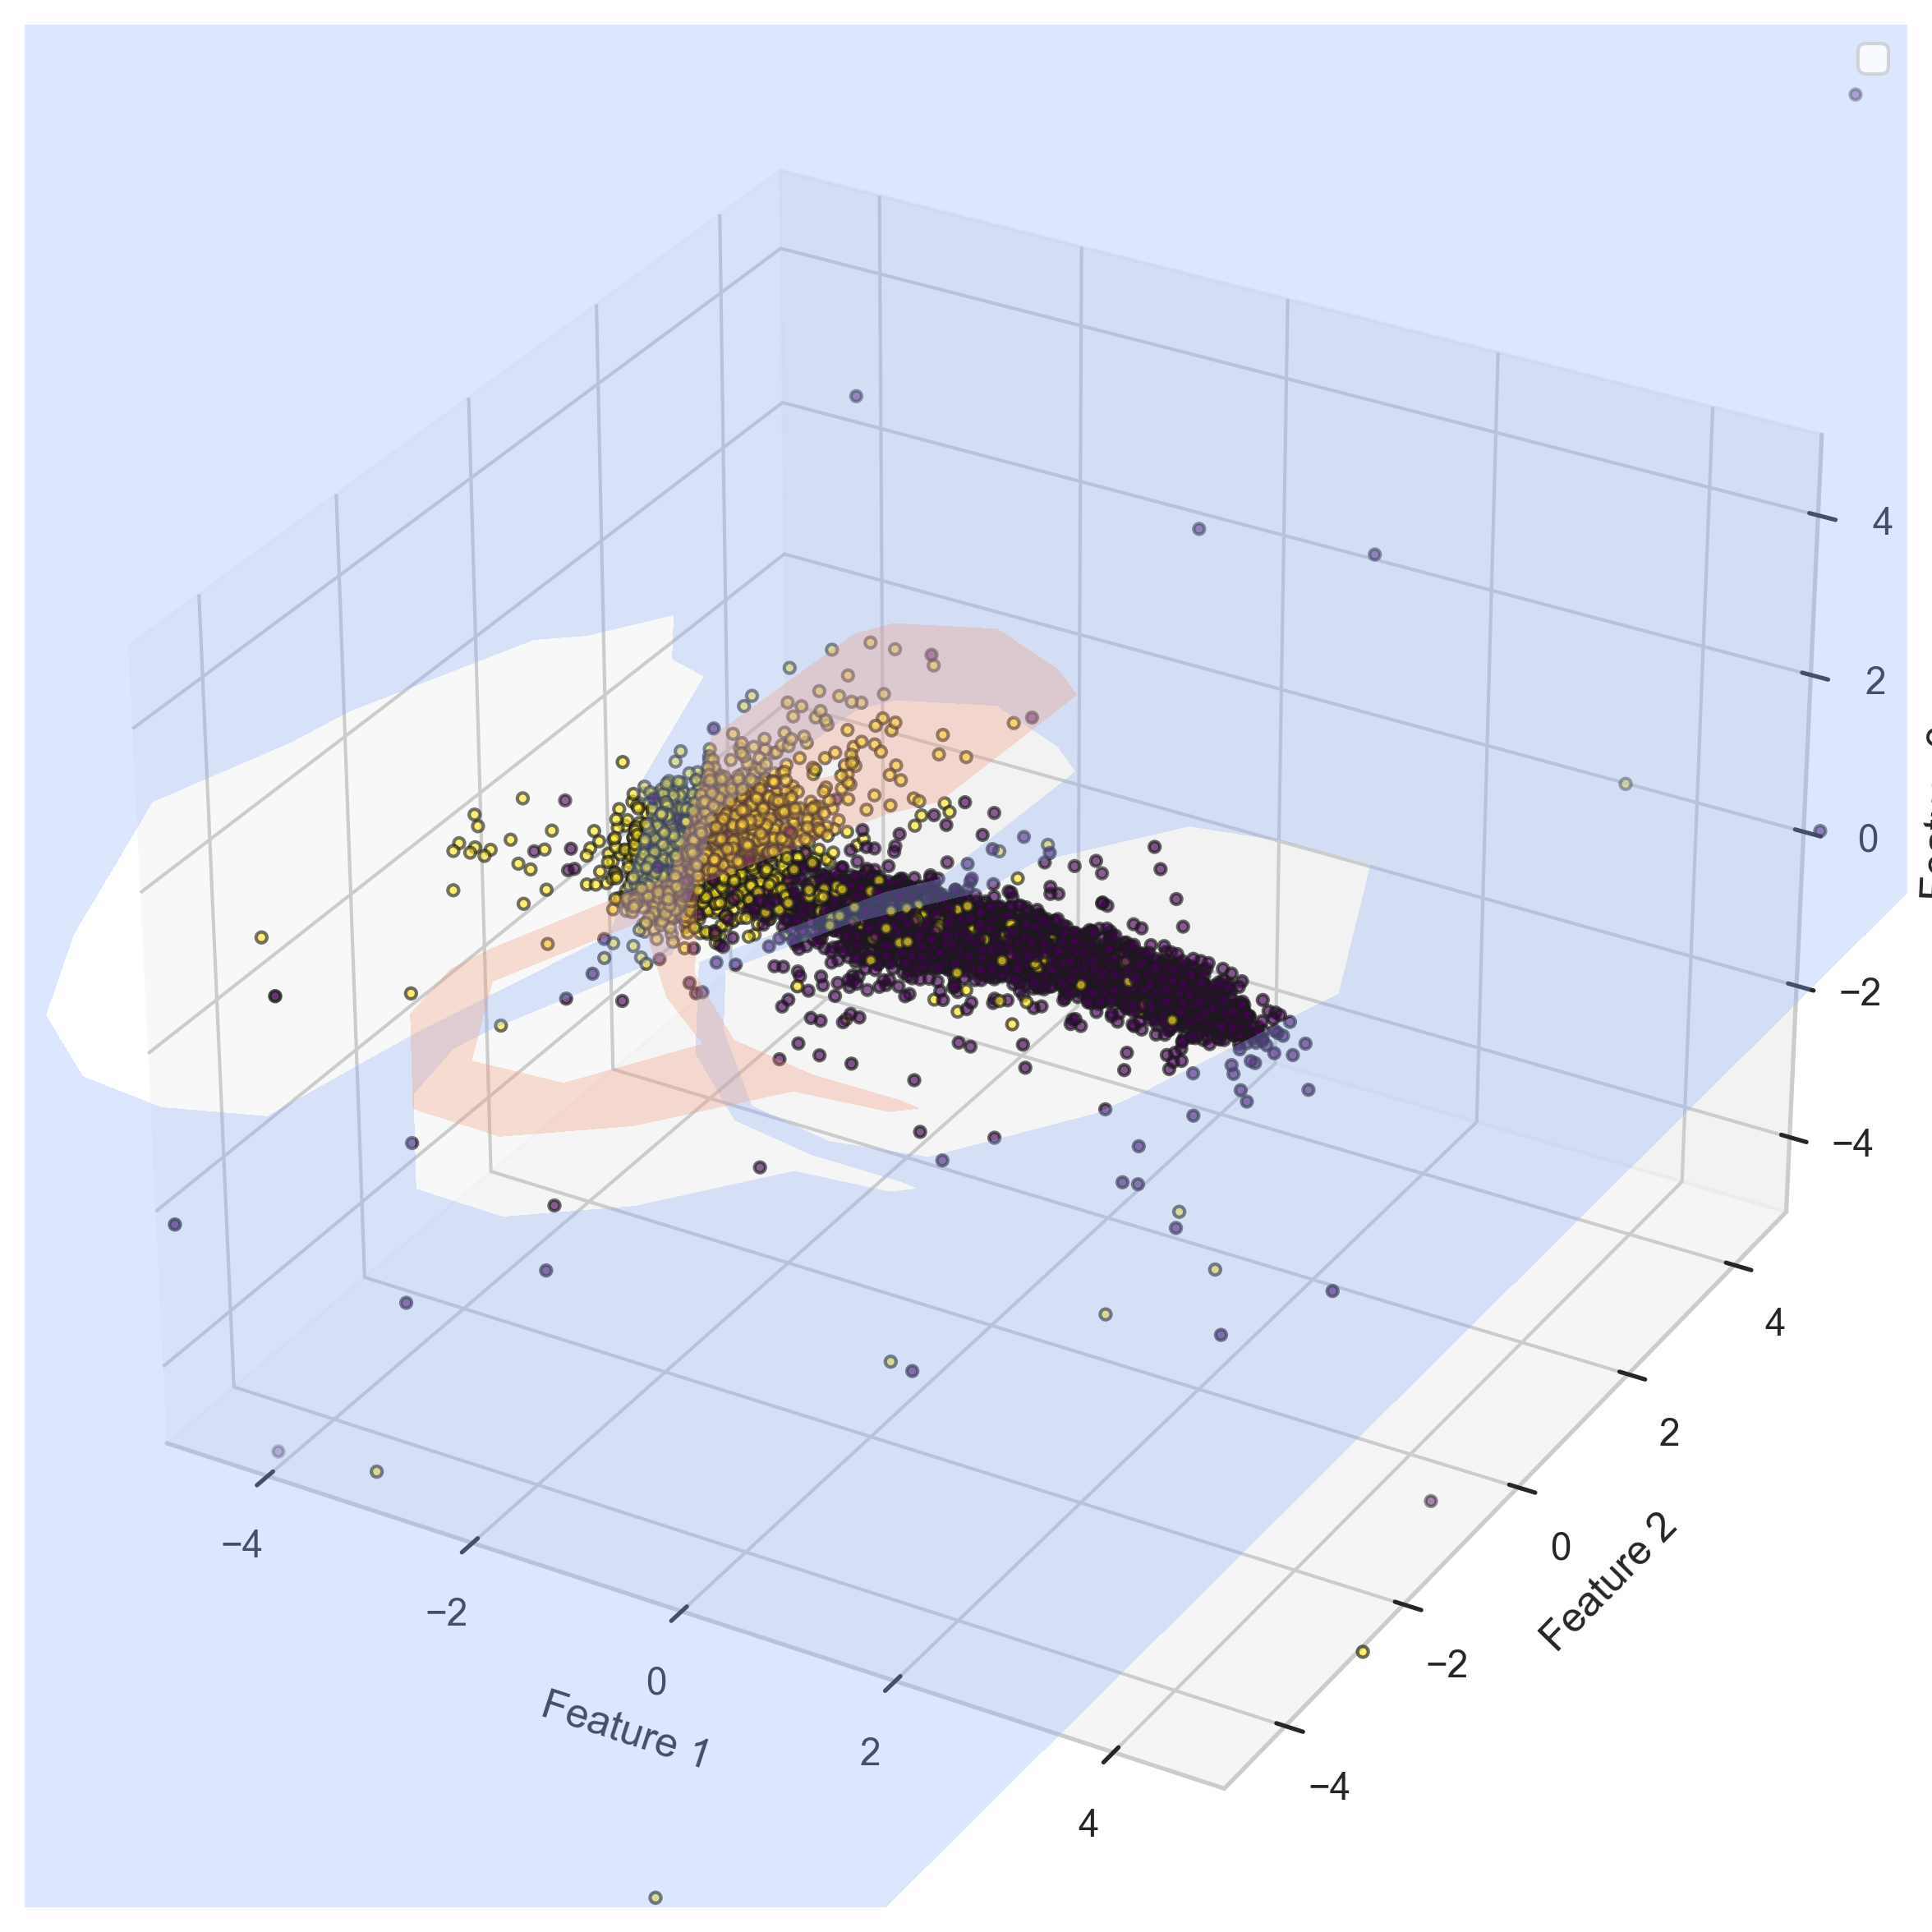

In [97]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#scatter = ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train, s=10, cmap='spring', edgecolor='k')
scatter2 = ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=y_test, s=10, cmap='viridis', edgecolor='k')

# Plot decision function
plot_svc_decision_function_3d(final_model, ax=ax)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-5, 5)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
#ax.view_init(elev=90, azim=-90)  # Rotate the plot
plt.legend()
plt.show()